In [2]:
import torch.nn as nn 
import torch

In [3]:
GPT_CONFIG_124M={
 "vocab_size":50257,
 "context_length":1024,
 "emb_dim":768,
 "n_heads":12,
 "n_layers":12,
 "drop_rate":0.1,
 "qkv_bias":False
}

GPT Architechture

In [4]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self,x):
        mean = x.mean(dim=-1,keepdim=True)
        var = x.var(dim=-1, keepdim=True,unbiased=False) ##If we use unbiased=True then will use basel correction= n-1 instead of n, which is normally used for sample data
        norm_x = (x-mean)/torch.sqrt(var+self.eps) ##To solve the issue of division by zero we use small epsilon
        return self.scale * norm_x + self.shift
    

class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self,x):
        return 0.5*x*(1+torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi))*
            (x + 0.044715 *torch.pow(x,3))
        ))        

class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"],4 * cfg["emb_dim"]), #Expansion
            GELU(),
            nn.Linear(4 * cfg['emb_dim'], cfg["emb_dim"]), ##Contraction
        )
    
    def forward(self,x):
        return self.layers(x)
    

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads ==0), \
        "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads ##Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_key = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.out_proj = nn.Linear(d_out,d_out) #Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length,context_length),diagonal=1)) #Context length considered and create upper triangle matrix with 1 and 0
    
    def forward(self,x):
        b,num_tokens,d_in = x.shape

        keys = self.W_key(x) #shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        #We implicitly split the matrix by adding a 'num_heads' dimension
        #Unroll last dim: (b,num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b,num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b,num_tokens, self.num_heads,self.head_dim)
    
        #Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        #Compute scaled dot-product attention - ie. self attention with causal mask
        attn_scores = queries @ keys.transpose(2,3) # Dot product for each head

        #Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]  ##mask is been register_buffer at __init__ method, 
                                        #this creates a upper triangle matrix with True in upper triangle and False in lower

        #Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf) ##mask_bool will have only True or False in matrix, those True will be added with -inf and those False will keep the original values from attn_scores

        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        #Shape: (b,num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1,2)

        #Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b,num_tokens,self.d_out)
        context_vec = self.out_proj(context_vec) #Optional projection

        return context_vec



In [6]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
    
        ##Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        #Use a placeholder for LayerNorm
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"],bias=False
        )
    
    def forward(self, in_idx): ##It takes the input- in_idx and returns output as logits
        batch_size, seq_len = in_idx.shape #batch_size = Rows, seq_len = Cols- number of tokens
        assert seq_len <= self.pos_emb.num_embeddings, \
            "Input sequence length exceeds maximum context length"
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device)) ##Pos emb depends on seq_len(context_size ie. 1024) and set pos values like 0,1, ... 1024
        pos_embeds = pos_embeds.unsqueeze(0).expand(batch_size, seq_len,-1)
        x = tok_embeds +pos_embeds  ##Token emb added with Pos emb
        x = self.drop_emb(x)  ##Drop out
        x = self.trf_blocks(x) ##In GPT2 we have 12 transformers each transformer will have multihead, layernorm, dropout, skip connection, forward block
        x = self.final_norm(x) ##We do layer normalization using DummyLayerNorm
        logits = self.out_head(x) ##
        return logits

class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.attn = MultiHeadAttention(
            d_in = cfg["emb_dim"],
            d_out = cfg["emb_dim"],
            context_length = cfg["context_length"],
            num_heads = cfg["n_heads"],
            dropout = cfg["drop_rate"],
            qkv_bias = cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
    
    def forward(self,x):
        #Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x) #Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x) 
        x = x + shortcut #Add the original input back
        
        #Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x) ##Also called pre normalization - done before a major program
        ##Original or initial Transformers were having layer norm after attn mechanism and feed forward neural network called Post Norm layer
        ##Later pre norm layer proved better than post norm layer
        x = self.ff(x)
        #2*4*768
        x= self.drop_shortcut(x)
        x = x + shortcut #Add the original input back , Add shortcut to prevent vanishing gradient

        return x


Compare ReLU and GELU for understanding via visualization

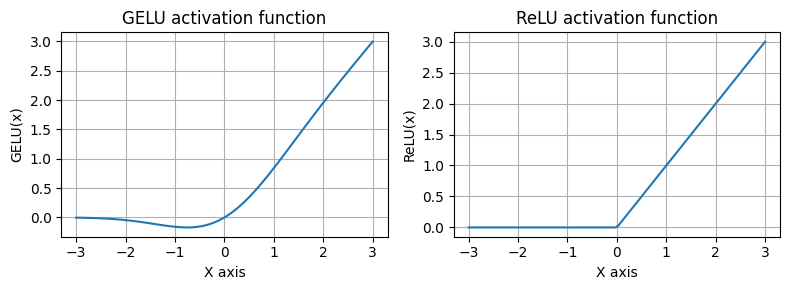

In [7]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3,3,100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8,3))
for i, (y,label) in enumerate(zip([y_gelu, y_relu],["GELU","ReLU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("X axis")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Where there is"
txt2 = "there is a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)


tensor([[8496,  612,  318],
        [8117,  318,  257]])


In [9]:
torch.manual_seed(45)
model = GPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output Shape",logits.shape)
print(logits) ##1st row matches to 1st token of word 'where'[-0.7222, -1.5904, -1.1890,  ..., -1.4170,  1.3657,  0.0328]
##Similarly there is, next "there is a". Each token will have 50257 dimensional vector
##Each of these 50,257 dimensions referes to a unique token in the vocabulary. At the end on full implementation the postprocessing code, we will
#Convert hese 50,257 dim vectors back into token IDs



Output Shape torch.Size([2, 3, 50257])
tensor([[[ 0.7283, -0.1271,  0.0537,  ...,  0.4032, -0.5427, -0.7259],
         [-0.2668, -0.4216,  0.7280,  ...,  0.2992, -0.4285,  0.2146],
         [ 0.6116,  0.5010,  0.5318,  ..., -0.5280,  0.6089, -1.0295]],

        [[ 0.2060, -0.6898, -0.5546,  ..., -0.1758, -0.6349, -0.5172],
         [ 0.2514, -0.5120,  0.0410,  ..., -0.0570,  0.5349, -0.5733],
         [-0.0549,  0.8713,  0.5421,  ...,  0.2741,  0.3616, -1.5169]]],
       grad_fn=<UnsafeViewBackward0>)


In [10]:
tot_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {tot_params:,}")

Total number of parameters: 163,009,536


In [11]:
tot_size_bytes = tot_params*4
tot_size_mb = tot_size_bytes/(1024*1024)
print(f"Total size of model: {tot_size_mb:.2f} MB")

Total size of model: 621.83 MB


In [19]:
###GPT Predict next token
def generate_text_simple(model,idx,max_new_tokens,context_size):
    #idx is (batch,n_tokens) array of indices in the current context
    # tensor([[8496,  612,  318],
    #     [8117,  318,  257]])
    
    for _ in range(max_new_tokens): ##Iteration repeated until reach max_new_tokens
        
        #Crop current context if it exceeds the supported context size
        #Eg. if LLM supports only 5 tokens, and the context size is 10 
        # then only the last 5 tokens are used as context
        idx_cond = idx[:,-context_size:]
        
        #Get the prediction
        with torch.no_grad():
            logits = model(idx_cond) ##Dimension are -> batch, n_tokens, vocab_size
        
        #Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:,-1,:] ##-1 in n_tokens means it will pick only last n_tokens for that batch
        
        #Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1) #batch, vocab_size
        ##Softmax is not necessary but to give the intuition and understand the highest value of word probab we use
        ##Softmax applied along every batch that is the rows
        
        #Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True) #(batch,1)
        
        #Append sampled index to the running sequence
        idx = torch.cat((idx,idx_next), dim=1) #(batch, n_tokens+1)
    
    return idx
            

In [13]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:",encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [21]:
model.eval()
#model = GPTModel(GPT_CONFIG_124M)
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print(f"Output:{out}")
print(f"Output length:{len(out[0])}")

Output:tensor([[15496,    11,   314,   716, 25033,  3863, 30327,   297, 29405,  7276]])
Output length:10


In [ ]:
decoded_txt = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_txt) ##This could be completely random result because its not yet trained. We need to train them.
##Its 124bn parameter model ready not yet trainined for our requirement.

Hello, I am physiological maybeAnthll clamp Care


--------------------Below Code is just for understanding purpose not sequential par of our code------------

Layer Normalization

In [ ]:
##Layer Normalization
torch.manual_seed(45)
batch_example = torch.randn(2,5)
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.3786, 0.0000, 0.1858, 0.5695, 0.0000, 0.4754],
        [0.0000, 0.5287, 0.0000, 0.1177, 0.5486, 0.8769]],
       grad_fn=<ReluBackward0>)


In [ ]:
avg = out.mean(dim=1,keepdim=True)
var = out.var(dim=1,keepdim=True)
print("Mean:\n",avg)
print("var:",var)


Mean:
 tensor([[0.2682],
        [0.3453]], grad_fn=<MeanBackward1>)
var: tensor([[0.0593],
        [0.1296]], grad_fn=<VarBackward0>)


In [ ]:
out_norm = (out-avg)/torch.sqrt(var)
mean = out_norm.mean(dim=-1,keepdim=True)
var = out_norm.var(dim=-1,keepdim=True)
torch.set_printoptions(sci_mode=False)
print("Normalized layer outputs:\n",out_norm)
print("mean:\n",mean)
print("variance:\n",var)

Normalized layer outputs:
 tensor([[ 0.4532, -1.1013, -0.3384,  1.2372, -1.1013,  0.8506],
        [-0.9593,  0.5093, -0.9593, -0.6323,  0.5647,  1.4769]],
       grad_fn=<DivBackward0>)
mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
variance:
 tensor([[1.],
        [1.]], grad_fn=<VarBackward0>)


GELU Activation function

In [ ]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers=nn.Sequential(
            nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"])
        )
    def forward(self,x):
        return self.layers(x)

print(GPT_CONFIG_124M,"emb_dim")
    

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False} emb_dim


ShortCut Connection - Skip connection

In [ ]:
class DNN(nn.Module):
    def __init__(self,layer_size, use_skip):
        super().__init__()
        self.use_skip = use_skip
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_size[0],layer_size[1]),nn.GELU()),
            nn.Sequential(nn.Linear(layer_size[1],layer_size[2]),nn.GELU()),
            nn.Sequential(nn.Linear(layer_size[2],layer_size[3]),nn.GELU()),
            nn.Sequential(nn.Linear(layer_size[3],layer_size[4]))
        ])
    
    def forward(self,x):
        out = x
        for layer in self.layers:
            #Compute output of current layer
            new_output = layer(out)
            #Check if shortcut can be applied
            if self.use_skip and out.shape==new_output.shape:
                out=out+new_output 
            else:
                out=new_output
        return out

            

In [ ]:
def print_grad(model,x):
    output = model(x)
    target=torch.tensor([[0.0]])
    criterion = nn.MSELoss()
    loss = criterion(output,target)
    # print(loss)
    loss.backward()
    for name,param in model.named_parameters():
        if 'weight' in name:
            if param.grad is not None:
                print(name, param.grad.abs().mean().item())
            else:
                print(name, "⚠️ No gradient (param.grad is None)")

In [ ]:

layer_sizes = [3,3,3,3,1]
sample = torch.tensor([[1.0,0.0,-1.0]])
torch.manual_seed(45)
model_without_shortcut = DNN(layer_sizes, use_skip=False)
print_grad(model_without_shortcut,sample)

layers.0.0.weight 0.0020218240097165108
layers.1.0.weight 0.002019670093432069
layers.2.0.weight 0.010838732123374939
layers.3.0.weight 0.04310139641165733


In [ ]:


torch.manual_seed(45)
model_with_shortcut = DNN(layer_sizes,use_skip=True)
print_grad(model_with_shortcut,sample)
    

layers.0.0.weight 0.06071154773235321
layers.1.0.weight 0.15079985558986664
layers.2.0.weight 0.047230321913957596
layers.3.0.weight 0.7033388018608093
